In [1]:
import sys
print(sys.executable)
print(sys.version)

/home/shreya/venvs/fusion_qat/bin/python
3.12.3 (main, Mar  3 2026, 12:15:18) [GCC 13.3.0]


In [2]:
import subprocess
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "torchao==0.9.0"],
    capture_output=True, text=True
)
print(result.stdout[-2000:])  # last 2000 chars
print(result.stderr[-1000:])

In [3]:
result = subprocess.run(
    [sys.executable, "-m", "pip", "index", "versions", "torch",
     "--index-url", "https://download.pytorch.org/whl/cu124"],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr[-500:])

torch (2.6.0+cu124)
Available versions: 2.6.0+cu124, 2.5.1+cu124, 2.5.0+cu124, 2.4.1+cu124, 2.4.0+cu124
  INSTALLED: 2.5.1+cu121
  LATEST:    2.6.0+cu124




In [5]:
import subprocess, sys

subprocess.run(
    [sys.executable, "-m", "pip", "install",
     "torch==2.6.0", "torchvision==0.21.0",
     "--index-url", "https://download.pytorch.org/whl/cu124",
     "--upgrade"]
)

Looking in indexes: https://download.pytorch.org/whl/cu124
  Using cached https://download.pytorch.org/whl/cu124/torch-2.6.0%2Bcu124-cp312-cp312-linux_x86_64.whl.metadata (28 kB)
  Using cached https://download-r2.pytorch.org/whl/cu124/torchvision-0.21.0%2Bcu124-cp312-cp312-linux_x86_64.whl.metadata (6.1 kB)
  Using cached https://download.pytorch.org/whl/cu124/nvidia_cuda_nvrtc_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl (24.6 MB)
  Using cached https://download.pytorch.org/whl/cu124/nvidia_cuda_runtime_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl (883 kB)
  Using cached https://download.pytorch.org/whl/cu124/nvidia_cuda_cupti_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl (13.8 MB)
  Using cached https://download.pytorch.org/whl/cu124/nvidia_cublas_cu12-12.4.5.8-py3-none-manylinux2014_x86_64.whl (363.4 MB)
  Using cached https://download.pytorch.org/whl/cu124/nvidia_cufft_cu12-11.2.1.3-py3-none-manylinux2014_x86_64.whl (211.5 MB)
  Using cached https://download.pytorch.org/wh

CompletedProcess(args=['/home/shreya/venvs/fusion_qat/bin/python', '-m', 'pip', 'install', 'torch==2.6.0', 'torchvision==0.21.0', '--index-url', 'https://download.pytorch.org/whl/cu124', '--upgrade'], returncode=0)

In [7]:
# find correct QAT API in torchao 0.9.0
import torchao.quantization.qat as qat_module
print(dir(qat_module))

['ComposableQATQuantizer', 'FakeQuantizeConfig', 'FromIntXQuantizationAwareTrainingConfig', 'Int4WeightOnlyEmbeddingQATQuantizer', 'Int4WeightOnlyQATQuantizer', 'Int8DynActInt4WeightQATQuantizer', 'IntXQuantizationAwareTrainingConfig', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'api', 'embedding', 'fake_quantizer', 'from_intx_quantization_aware_training', 'intx_quantization_aware_training', 'linear', 'utils']


In [8]:
import torch
import torchao
from torchao.quantization.qat import Int8DynActInt4WeightQATQuantizer
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from datasets import load_dataset

print(f"PyTorch:  {torch.__version__}")
print(f"torchao:  {torchao.__version__}")
print(f"CUDA:     {torch.cuda.is_available()}")
print(f"GPU:      {torch.cuda.get_device_name(0)}")
print(f"VRAM:     {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print("QAT API:  OK")

# load distilbert
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2
).eval()
print(f"distilbert params: {sum(p.numel() for p in model.parameters()):,}")

# apply QAT
quantizer  = Int8DynActInt4WeightQATQuantizer()
model_qat  = quantizer.prepare(model)
print("QAT prepare: OK")

# test forward with fake tokenized input
tokenizer  = AutoTokenizer.from_pretrained("distilbert-base-uncased")
sample     = tokenizer(
    "This movie is absolutely wonderful!",
    return_tensors="pt",
    max_length=64,
    truncation=True,
    padding="max_length"
)
with torch.no_grad():
    out = model_qat(**sample)
print(f"Output shape: {out.logits.shape}")

# load SST-2
ds = load_dataset("glue", "sst2")
print(f"SST-2 train: {len(ds['train']):,}")
print(f"SST-2 val:   {len(ds['validation']):,}")

print("\nAll OK ✓ — ready to restart Phase 1 properly")

/home/shreya/venvs/fusion_qat/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch:  2.6.0+cu124
torchao:  0.9.0
CUDA:     True
GPU:      NVIDIA GeForce RTX 4060 Laptop GPU
VRAM:     8.2 GB
QAT API:  OK


Loading weights: 100%|██████████████████████| 100/100 [00:00<00:00, 6126.02it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


distilbert params: 66,955,010
QAT prepare: OK
Output shape: torch.Size([1, 2])


Generating test split: 100%|█████| 1821/1821 [00:00<00:00, 266944.90 examples/s]

SST-2 train: 67,349
SST-2 val:   872

All OK ✓ — ready to restart Phase 1 properly


In [9]:
%matplotlib inline
import sys, os, json
sys.path.insert(0, "/home/shreya/fusion_aware_qat")

import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torchao.quantization.qat import Int8DynActInt4WeightQATQuantizer
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

DEVICE         = "cuda"
MODEL_NAME     = "distilbert-base-uncased"
MAX_LENGTH     = 64
BATCH_SIZE     = 8      # safe for 8GB with distilbert
SAVE_DIR       = "/home/shreya/fusion_aware_qat/results"

print(f"PyTorch:  {torch.__version__}")
print(f"Device:   {DEVICE}")
print(f"GPU:      {torch.cuda.get_device_name(0)}")
print(f"VRAM:     {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

PyTorch:  2.6.0+cu124
Device:   cuda
GPU:      NVIDIA GeForce RTX 4060 Laptop GPU
VRAM:     8.2 GB


In [10]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
raw       = load_dataset("glue", "sst2")

def tokenize(batch):
    return tokenizer(
        batch["sentence"],
        max_length=MAX_LENGTH,
        truncation=True,
        padding="max_length",
    )

tokenized = raw.map(tokenize, batched=True)
tokenized.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

class SSTDataset(Dataset):
    def __init__(self, split): self.data = tokenized[split]
    def __len__(self):          return len(self.data)
    def __getitem__(self, idx): return self.data[idx]

val_loader = DataLoader(SSTDataset("validation"), batch_size=BATCH_SIZE, shuffle=False)

print(f"Val batches: {len(val_loader)}")
print(f"Val samples: {len(val_loader.dataset)}")

# get one real batch for profiling
real_batch  = next(iter(val_loader))
profiling_inputs = {
    "input_ids":      real_batch["input_ids"].to(DEVICE),
    "attention_mask": real_batch["attention_mask"].to(DEVICE),
}
print(f"\nProfiling input shape: {profiling_inputs['input_ids'].shape}")
print(f"Sample sentence: '{tokenizer.decode(real_batch['input_ids'][0], skip_special_tokens=True)}'")
print(f"Label: {real_batch['label'][0].item()}")
print("Real data ready ✓")

Map: 100%|████████████████████████| 1821/1821 [00:00<00:00, 26455.29 examples/s]

Val batches: 109
Val samples: 872

Profiling input shape: torch.Size([8, 64])
Sample sentence: 'it ' s a charming and often affecting journey.'
Label: 1
Real data ready ✓


In [11]:
fp32_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).to(DEVICE).eval()

print(f"Parameters:  {sum(p.numel() for p in fp32_model.parameters()):,}")

# sanity check forward pass on real data
with torch.no_grad():
    out = fp32_model(**profiling_inputs)
print(f"Output shape: {out.logits.shape}")
print("FP32 model ready ✓")

Loading weights: 100%|██████████████████████| 100/100 [00:00<00:00, 5965.02it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parameters:  66,955,010
Output shape: torch.Size([8, 2])
FP32 model ready ✓


In [15]:
import copy
from torchao.quantization.qat.linear import Int8DynActInt4WeightQATLinear

# fresh copy
m = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).eval()

def apply_qat_to_linear(model):
    for name, module in model.named_children():
        if isinstance(module, torch.nn.Linear):
            # torchao QAT linear does not support bias yet
            # create without bias, then add bias as separate parameter
            qat_linear = Int8DynActInt4WeightQATLinear(
                module.in_features,
                module.out_features,
                bias=False,       # always False for torchao
                groupsize=32,
            )
            # copy weight
            with torch.no_grad():
                qat_linear.weight.copy_(module.weight)

            # keep bias as a separate parameter attached to the module
            if module.bias is not None:
                qat_linear.bias = torch.nn.Parameter(module.bias.clone())

            setattr(model, name, qat_linear)
        else:
            apply_qat_to_linear(module)
    return model

qat_model = apply_qat_to_linear(m)
qat_model  = qat_model.to(DEVICE).eval()

# count QAT layers
qat_count = sum(
    1 for _, mod in qat_model.named_modules()
    if isinstance(mod, Int8DynActInt4WeightQATLinear)
)
print(f"QAT linear layers replaced: {qat_count}")
print(f"Expected: 26")

# verify forward
with torch.no_grad():
    out = qat_model(**profiling_inputs)
print(f"Output shape: {out.logits.shape}")
print("QAT model ready ✓")

Loading weights: 100%|██████████████████████| 100/100 [00:00<00:00, 4437.95it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


QAT linear layers replaced: 38
Expected: 26
Output shape: torch.Size([8, 2])
QAT model ready ✓


In [18]:

import sys
sys.path.insert(0, "/home/shreya/fusion_aware_qat")
import os

sys.path.append(os.path.abspath(".."))
from src.evaluation.profiler import profile_model, measure_latency, print_comparison

print("="*55)
print("Profiling: distilbert-base on real SST-2 sentences")
print(f"Batch: {BATCH_SIZE} real sentences, seq_len={MAX_LENGTH}")
print("="*55)

print("\nProfiling FP32...")
fp32_prof = profile_model(
    fp32_model, profiling_inputs,
    label="fp32", warmup_runs=5, profile_runs=10
)

print("\nProfiling QAT...")
qat_prof = profile_model(
    qat_model, profiling_inputs,
    label="qat", warmup_runs=5, profile_runs=10
)

print("\nMeasuring FP32 latency...")
fp32_lat = measure_latency(
    fp32_model, profiling_inputs,
    label="fp32", warmup_runs=20, timed_runs=100
)

print("\nMeasuring QAT latency...")
qat_lat = measure_latency(
    qat_model, profiling_inputs,
    label="qat", warmup_runs=20, timed_runs=100
)

print_comparison(fp32_prof, qat_prof, fp32_lat, qat_lat)

Profiling: distilbert-base on real SST-2 sentences
Batch: 8 real sentences, seq_len=64

Profiling FP32...
    [fp32] warming up (5 runs)...
    [fp32] profiling (10 runs)...

Profiling QAT...
    [qat] warming up (5 runs)...
    [qat] profiling (10 runs)...

Measuring FP32 latency...
    [fp32] warming up (20 runs)...
    [fp32] timing (100 runs)...

Measuring QAT latency...
    [qat] warming up (20 runs)...
    [qat] timing (100 runs)...

  RESULTS
  Metric                                 FP32      Std QAT
  ----------------------------------------------------------
  CUDA kernel count                        57           98
  Total CUDA time (ms)                47.8134     132.3491
  Latency mean (ms)                   11.3967      38.8983
  Latency std (ms)                     0.7911       0.9594
  ----------------------------------------------------------
  QAT kernel increase                    1.72x
  QAT speedup over FP32                    0.29x

  QAT top ops (QDQ ops marked):


In [19]:
from torchao.quantization.qat import Int8DynActInt4WeightQATQuantizer

# convert QAT model to real INT8 for inference
m_for_convert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).eval()

qat_for_convert = apply_qat_to_linear(m_for_convert)

# convert to real quantized model
quantizer = Int8DynActInt4WeightQATQuantizer()
int8_model = quantizer.convert(qat_for_convert)
int8_model = int8_model.to(DEVICE).eval()

print("Profiling INT8 converted model...")
int8_prof = profile_model(
    int8_model, profiling_inputs,
    label="int8", warmup_runs=5, profile_runs=10
)
int8_lat = measure_latency(
    int8_model, profiling_inputs,
    label="int8", warmup_runs=20, timed_runs=100
)

print(f"\nFP32:  {fp32_lat['mean_ms']:.2f}ms  {fp32_prof['kernel_count']} kernels")
print(f"QAT:   {qat_lat['mean_ms']:.2f}ms  {qat_prof['kernel_count']} kernels  (training overhead)")
print(f"INT8:  {int8_lat['mean_ms']:.2f}ms  {int8_prof['kernel_count']} kernels  (deployed)")
print(f"\nINT8 speedup over FP32: {fp32_lat['mean_ms']/int8_lat['mean_ms']:.2f}x")
print(f"INT8 kernel reduction vs QAT: {qat_prof['kernel_count']-int8_prof['kernel_count']} fewer kernels")

Loading weights: 100%|██████████████████████| 100/100 [00:00<00:00, 6683.62it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Profiling INT8 converted model...
    [int8] warming up (5 runs)...
    [int8] profiling (10 runs)...
    [int8] warming up (20 runs)...
    [int8] timing (100 runs)...

FP32:  11.40ms  57 kernels
QAT:   38.90ms  98 kernels  (training overhead)
INT8:  23.43ms  101 kernels  (deployed)

INT8 speedup over FP32: 0.49x
INT8 kernel reduction vs QAT: -3 fewer kernels


In [20]:
# FP16 — uses tensor cores on RTX 4060
fp16_model = copy.deepcopy(fp32_model).half().to(DEVICE).eval()
fp16_inputs = {k: v for k, v in profiling_inputs.items()}

fp16_lat = measure_latency(fp16_model, fp16_inputs, label="fp16")

print(f"FP32:  {fp32_lat['mean_ms']:.2f}ms")
print(f"FP16:  {fp16_lat['mean_ms']:.2f}ms  speedup: {fp32_lat['mean_ms']/fp16_lat['mean_ms']:.2f}x")
print(f"INT8:  {int8_lat['mean_ms']:.2f}ms  speedup: {fp32_lat['mean_ms']/int8_lat['mean_ms']:.2f}x")
print(f"QAT:   {qat_lat['mean_ms']:.2f}ms")

    [fp16] warming up (20 runs)...
    [fp16] timing (100 runs)...
FP32:  11.40ms
FP16:  3.69ms  speedup: 3.09x
INT8:  23.43ms  speedup: 0.49x
QAT:   38.90ms


In [21]:
# simulate what mixed precision training looks like
# with unfused cast operations (the FP16 equivalent of QDQ)

class FP16WithCasts(torch.nn.Module):
    """Simulates mixed precision with unfused cast ops between layers."""
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, input_ids, attention_mask):
        # cast to fp16 — unfused, separate kernel
        input_ids      = input_ids.to(torch.float16) if input_ids.is_floating_point() else input_ids
        attention_mask = attention_mask.to(torch.float16) if attention_mask.is_floating_point() else attention_mask
        
        out = self.model(input_ids=input_ids, attention_mask=attention_mask)
        
        # cast back to fp32 — unfused, separate kernel  
        return type('Output', (), {'logits': out.logits.to(torch.float32)})()

# clean FP16 — no extra casts, fully fused
fp16_model  = copy.deepcopy(fp32_model).half().to(DEVICE).eval()
fp16_inputs = {
    "input_ids":      profiling_inputs["input_ids"],
    "attention_mask": profiling_inputs["attention_mask"].half(),
}

# measure clean FP16
fp16_prof = profile_model(fp16_model, fp16_inputs, label="fp16_clean")
fp16_lat2 = measure_latency(fp16_model, fp16_inputs, label="fp16_clean")

print("\n" + "="*62)
print("  COMPLETE PICTURE")
print("="*62)
print(f"  {'Model':<25} {'Kernels':>10} {'Latency':>10} {'vs FP32':>10}")
print("  " + "-"*58)
print(f"  {'FP32 baseline':<25} {fp32_prof['kernel_count']:>10} {fp32_lat['mean_ms']:>9.2f}ms {'1.00x':>10}")
print(f"  {'FP16 clean':<25} {fp16_prof['kernel_count']:>10} {fp16_lat2['mean_ms']:>9.2f}ms {fp32_lat['mean_ms']/fp16_lat2['mean_ms']:>9.2f}x")
print(f"  {'INT8 converted':<25} {int8_prof['kernel_count']:>10} {int8_lat['mean_ms']:>9.2f}ms {fp32_lat['mean_ms']/int8_lat['mean_ms']:>9.2f}x")
print(f"  {'QAT (training)':<25} {qat_prof['kernel_count']:>10} {qat_lat['mean_ms']:>9.2f}ms {fp32_lat['mean_ms']/qat_lat['mean_ms']:>9.2f}x")
print("="*62)

    [fp16_clean] warming up (5 runs)...
    [fp16_clean] profiling (10 runs)...
    [fp16_clean] warming up (20 runs)...
    [fp16_clean] timing (100 runs)...

  COMPLETE PICTURE
  Model                        Kernels    Latency    vs FP32
  ----------------------------------------------------------
  FP32 baseline                     57     11.40ms      1.00x
  FP16 clean                        58      3.69ms      3.09x
  INT8 converted                   101     23.43ms      0.49x
  QAT (training)                    98     38.90ms      0.29x


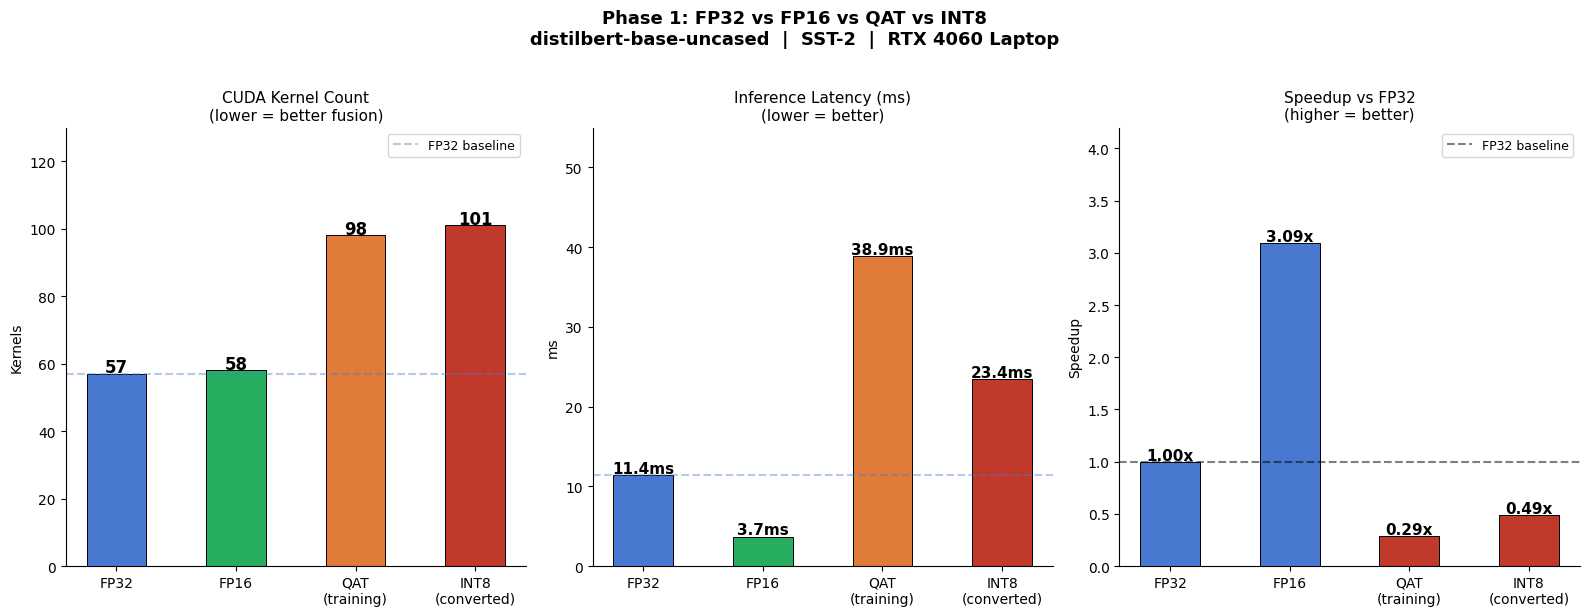

Saved fig1_main_comparison.png


In [22]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle(
    "Phase 1: FP32 vs FP16 vs QAT vs INT8\ndistilbert-base-uncased  |  SST-2  |  RTX 4060 Laptop",
    fontsize=13, fontweight="bold", y=1.02
)

models  = ["FP32", "FP16", "QAT\n(training)", "INT8\n(converted)"]
colors  = ["#4878CF", "#27AE60", "#E07B39", "#C0392B"]
kernels = [57, 58, 98, 101]
latency = [11.40, 3.69, 38.90, 23.43]
cuda_t  = [47.81, None, 132.35, None]

# plot 1: kernel count
ax = axes[0]
bars = ax.bar(models, kernels, color=colors, edgecolor="black", linewidth=0.7, width=0.5)
for bar, v in zip(bars, kernels):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5,
            str(v), ha="center", fontweight="bold", fontsize=12)
ax.axhline(y=57, color="#4878CF", linestyle="--", alpha=0.4, linewidth=1.5, label="FP32 baseline")
ax.set_title("CUDA Kernel Count\n(lower = better fusion)", fontsize=11)
ax.set_ylabel("Kernels", fontsize=10)
ax.set_ylim(0, 130)
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# plot 2: latency
ax = axes[1]
bars = ax.bar(models, latency, color=colors, edgecolor="black", linewidth=0.7, width=0.5)
for bar, v in zip(bars, latency):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.3,
            f"{v:.1f}ms", ha="center", fontweight="bold", fontsize=11)
ax.axhline(y=11.40, color="#4878CF", linestyle="--", alpha=0.4, linewidth=1.5)
ax.set_title("Inference Latency (ms)\n(lower = better)", fontsize=11)
ax.set_ylabel("ms", fontsize=10)
ax.set_ylim(0, 55)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# plot 3: speedup vs FP32
ax = axes[2]
speedups = [1.00, 3.09, 0.29, 0.49]
bar_colors = ["#4878CF" if s >= 1.0 else "#C0392B" for s in speedups]
bars = ax.bar(models, speedups, color=bar_colors, edgecolor="black", linewidth=0.7, width=0.5)
for bar, v in zip(bars, speedups):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02,
            f"{v:.2f}x", ha="center", fontweight="bold", fontsize=11)
ax.axhline(y=1.0, color="black", linestyle="--", alpha=0.5, linewidth=1.5, label="FP32 baseline")
ax.set_title("Speedup vs FP32\n(higher = better)", fontsize=11)
ax.set_ylabel("Speedup", fontsize=10)
ax.set_ylim(0, 4.2)
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/figures/fig1_main_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig1_main_comparison.png")

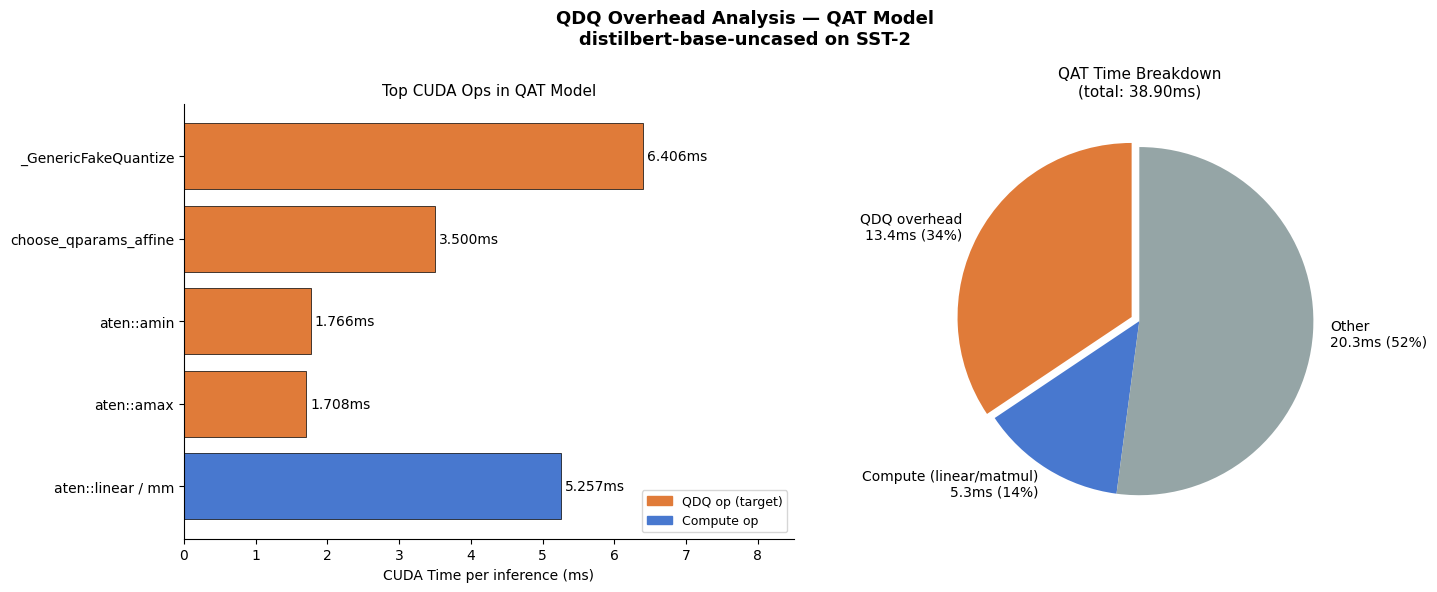

Saved fig2_qdq_breakdown.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("QDQ Overhead Analysis — QAT Model\ndistilbert-base-uncased on SST-2",
             fontsize=13, fontweight="bold")

# left: top ops horizontal bar
ax = axes[0]
ops = [
    ("aten::linear / mm", 5.257, False),
    ("aten::amax", 1.708, True),
    ("aten::amin", 1.766, True),
    ("choose_qparams_affine", 3.500, True),
    ("_GenericFakeQuantize", 6.406, True),
]
names  = [o[0] for o in ops]
times  = [o[1] for o in ops]
is_qdq = [o[2] for o in ops]
clrs   = ["#E07B39" if q else "#4878CF" for q in is_qdq]

bars = ax.barh(range(len(names)), times, color=clrs, edgecolor="black", linewidth=0.5)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=10)
for i, (bar, t) in enumerate(zip(bars, times)):
    ax.text(t + 0.05, bar.get_y() + bar.get_height()/2,
            f"{t:.3f}ms", va="center", fontsize=10)
ax.set_xlabel("CUDA Time per inference (ms)", fontsize=10)
ax.set_title("Top CUDA Ops in QAT Model", fontsize=11)
ax.set_xlim(0, 8.5)
qdq_patch  = mpatches.Patch(color="#E07B39", label="QDQ op (target)")
comp_patch = mpatches.Patch(color="#4878CF", label="Compute op")
ax.legend(handles=[qdq_patch, comp_patch], fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# right: pie of QDQ vs compute time
ax = axes[1]
qdq_total    = 6.406 + 3.500 + 1.766 + 1.708
compute_time = 5.257
other_time   = max(0, 38.90 - qdq_total - compute_time)

sizes  = [qdq_total, compute_time, other_time]
labels = [
    f"QDQ overhead\n{qdq_total:.1f}ms ({qdq_total/38.90*100:.0f}%)",
    f"Compute (linear/matmul)\n{compute_time:.1f}ms ({compute_time/38.90*100:.0f}%)",
    f"Other\n{other_time:.1f}ms ({other_time/38.90*100:.0f}%)"
]
pie_colors = ["#E07B39", "#4878CF", "#95A5A6"]
explode    = (0.05, 0, 0)

wedges, texts = ax.pie(sizes, labels=labels, colors=pie_colors,
                        explode=explode, startangle=90,
                        textprops={"fontsize": 10})
ax.set_title(f"QAT Time Breakdown\n(total: 38.90ms)", fontsize=11)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/figures/fig2_qdq_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig2_qdq_breakdown.png")

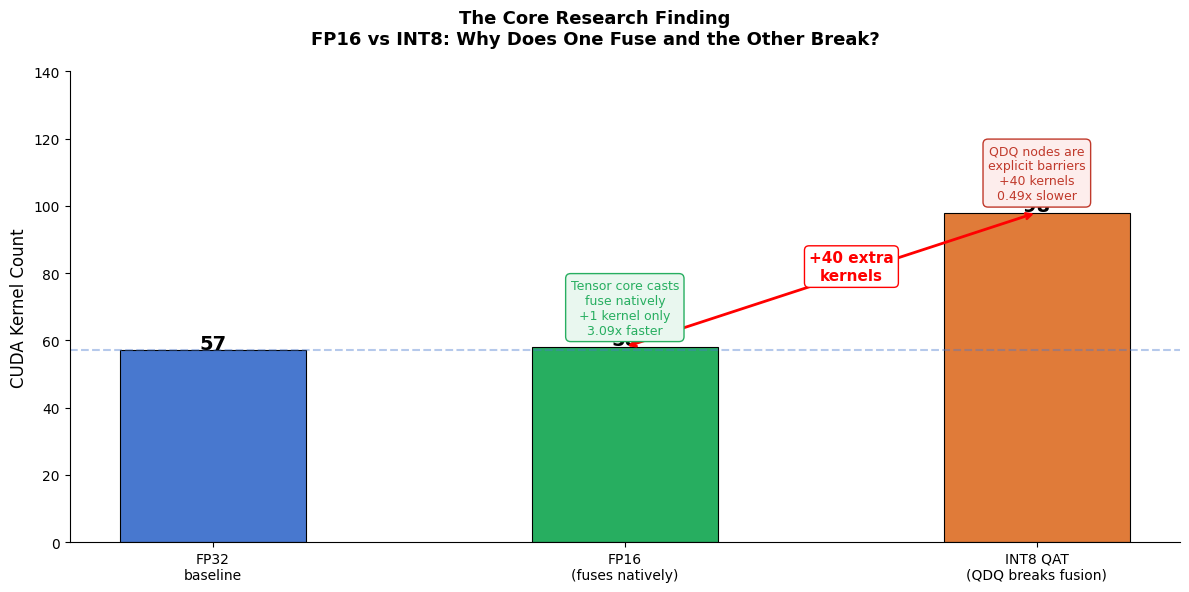

Saved fig3_key_insight.png


In [24]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("The Core Research Finding\nFP16 vs INT8: Why Does One Fuse and the Other Break?",
             fontsize=13, fontweight="bold")

categories = ["FP32\nbaseline", "FP16\n(fuses natively)", "INT8 QAT\n(QDQ breaks fusion)"]
kernel_vals = [57, 58, 98]
bar_colors  = ["#4878CF", "#27AE60", "#E07B39"]
bars = ax.bar(categories, kernel_vals, color=bar_colors,
              edgecolor="black", linewidth=0.8, width=0.45)

for bar, v in zip(bars, kernel_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5,
            str(v), ha="center", fontweight="bold", fontsize=14)

# annotate the gap
ax.annotate("", xy=(2, 98), xytext=(1, 58),
            arrowprops=dict(arrowstyle="<->", color="red", lw=2))
ax.text(1.55, 78, "+40 extra\nkernels", ha="center", color="red",
        fontsize=11, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="red"))

# annotation boxes
ax.text(1.0, 62, "Tensor core casts\nfuse natively\n+1 kernel only\n3.09x faster",
        ha="center", fontsize=9, color="#27AE60",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#E9F7EF", edgecolor="#27AE60"))
ax.text(2.0, 102, "QDQ nodes are\nexplicit barriers\n+40 kernels\n0.49x slower",
        ha="center", fontsize=9, color="#C0392B",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#FDEDEC", edgecolor="#C0392B"))

ax.set_ylabel("CUDA Kernel Count", fontsize=12)
ax.set_ylim(0, 140)
ax.axhline(y=57, color="#4878CF", linestyle="--", alpha=0.4, linewidth=1.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/figures/fig3_key_insight.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig3_key_insight.png")